In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/479_706.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/481_469.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/184_205.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/315_322.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/645_688.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/700_813.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/313_283.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/336_338.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/746_571.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/917_924.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/207_908.mp4
/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Face2Face/297_270.mp4
/kaggle/input/datasets/xdxd003/ff-c23/Fa

In [2]:
# ============================================================
# ENVIRONMENT SETUP — run this first, every session
# --no-deps is deliberate: prevents facenet-pytorch from pulling in a
# different numpy/torch/torchvision/Pillow than what Kaggle already has
# installed together (and already mutually compatible). Letting pip'''s
# resolver touch those is what caused the numpy ABI corruption and the
# Pillow/torchvision conflict in earlier attempts.
# ============================================================
!pip install -q --no-deps facenet-pytorch==2.6.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.0 MB/s eta 0:00:00


In [3]:
# ============================================================
# PATCH: restore is_directory/is_path to PIL._util BEFORE importing
# torchvision. Newer Pillow (needed by facenet-pytorch) removed these,
# which breaks torchvision's ImageFont import chain. This is not
# fixable by picking a Pillow/torchvision version — no compatible pair
# exists — so we patch the two missing functions back in directly.
# ============================================================
import os
import PIL._util as _util

if not hasattr(_util, "is_directory"):
    _util.is_directory = lambda path: os.path.isdir(path)
if not hasattr(_util, "is_path"):
    _util.is_path = lambda path: isinstance(path, (bytes, str, os.PathLike))

import torch, torchvision, PIL
import importlib.metadata

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Pillow:", PIL.__version__)
print("facenet-pytorch:", importlib.metadata.version("facenet-pytorch"))
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from facenet_pytorch import MTCNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_test_mtcnn = MTCNN(keep_all=True, device=device)
print("facenet-pytorch import + MTCNN init: OK")


Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Pillow: 11.3.0
facenet-pytorch: 2.6.0
CUDA available: True
GPU: Tesla T4
facenet-pytorch import + MTCNN init: OK


In [4]:
# ============================================================
# LOAD SHARED PROJECT UTILITIES
# Update REPO_URL if your canonical repo differs.
# ============================================================
import os, sys

REPO_URL = "https://github.com/Mugdha-Naik/deepfake-detector-project.git"
REPO_DIR = "/kaggle/working/repo"

if not os.path.exists(REPO_DIR):
    os.system(f"git clone {REPO_URL} {REPO_DIR}")
else:
    os.system(f"cd {REPO_DIR} && git pull")

sys.path.append(REPO_DIR)

from utils import (
    get_kaggle_video_path, verify_path_resolution, get_label_from_path,
    load_mtcnn, extract_faces_from_video,
    CELEB_ROOT, FF_ROOT, CSV_URL, MIN_CONFIDENCE, FRAME_INTERVAL,
)

print("utils.py loaded successfully")


Cloning into '/kaggle/working/repo'...


utils.py loaded successfully


In [5]:
# ============================================================
# LOAD SHARED PROJECT UTILITIES
# Update REPO_URL if your canonical repo differs.
# ============================================================
import os, sys

REPO_URL = "https://github.com/Mugdha-Naik/deepfake-detector-project.git"
REPO_DIR = "/kaggle/working/repo"

if not os.path.exists(REPO_DIR):
    os.system(f"git clone {REPO_URL} {REPO_DIR}")
else:
    os.system(f"cd {REPO_DIR} && git pull")

sys.path.append(REPO_DIR)

from utils import (
    get_kaggle_video_path, verify_path_resolution, get_label_from_path,
    load_mtcnn, extract_faces_from_video,
    CELEB_ROOT, FF_ROOT, CSV_URL, MIN_CONFIDENCE, FRAME_INTERVAL,
)

print("utils.py loaded successfully")


Already up to date.
utils.py loaded successfully


In [6]:
import cv2
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

print("Celeb-DF exists:", os.path.exists(CELEB_ROOT))
print("FF++ exists:", os.path.exists(FF_ROOT))

Celeb-DF exists: True
FF++ exists: True


In [7]:
# ============================================================
# LOAD VERIFIED VIDEO LIST (output of Steps 1-3 cleaning)
# ============================================================
df = pd.read_csv(CSV_URL)
print("Total videos:", len(df))

df["kaggle_path"] = df["video_path"].apply(get_kaggle_video_path)
df["exists"] = df["kaggle_path"].apply(lambda p: os.path.exists(p) if p else False)
df["label"] = df["video_path"].apply(get_label_from_path)

print("Found:", df["exists"].sum(), "| Missing:", (~df["exists"]).sum())
print("\nLabel distribution:")
print(df["label"].value_counts())


Total videos: 13529
Found: 13529 | Missing: 0

Label distribution:
label
FAKE    11639
REAL     1890
Name: count, dtype: int64


In [8]:
# ============================================================
# VERIFY: check both REAL and FAKE paths resolve correctly
# before running the full extraction.
# ============================================================
verify_path_resolution(df)


data/raw\cel\Celeb-real\id0_0000.mp4 -> /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id0_0000.mp4 | exists: True
data/raw\cel\Celeb-real\id0_0001.mp4 -> /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real/id0_0001.mp4 | exists: True
data/raw\FaceForensics++_C23\DeepFakeDetection\01_02__meeting_serious__YVGY8LOK.mp4 -> /kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/DeepFakeDetection/01_02__meeting_serious__YVGY8LOK.mp4 | exists: True
data/raw\FaceForensics++_C23\DeepFakeDetection\01_02__outside_talking_still_laughing__YVGY8LOK.mp4 -> /kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/DeepFakeDetection/01_02__outside_talking_still_laughing__YVGY8LOK.mp4 | exists: True


In [9]:
mtcnn, device = load_mtcnn()

MTCNN loaded. Device: cuda


In [10]:
OUTPUT_DIR = "/kaggle/working/step4_faces"
FACES_DIR = os.path.join(OUTPUT_DIR, "faces")
os.makedirs(FACES_DIR, exist_ok=True)
print("Faces directory:", FACES_DIR)

Faces directory: /kaggle/working/step4_faces/faces


In [11]:
# ============================================================
# MAIN EXTRACTION LOOP
# Change NUM_VIDEOS to len(df) once a small batch is verified working.
# sampling="interval" matches the Step 4/5 convention — see the
# TEAM DECISION note in utils.py before changing this.
# ============================================================
NUM_VIDEOS = 10   # <-- set to len(df) for the full run
run_df = df.head(NUM_VIDEOS)

all_records = []

for video_index, row in tqdm(run_df.iterrows(), total=len(run_df), desc="Step 4"):
    video_path = row["kaggle_path"]
    label = row["label"]

    if not video_path or not os.path.exists(video_path):
        print("Missing:", row["video_path"])
        continue

    video_id = os.path.splitext(os.path.basename(row["video_path"]))[0]

    records = extract_faces_from_video(
        video_path=video_path,
        label_name=label,
        faces_dir=FACES_DIR,
        video_id=video_id,
        mtcnn=mtcnn,
        sampling="interval",
    )
    all_records.extend(records)
    print(f"{video_index + 1}/{len(run_df)} | label: {label} | faces saved: {len(records)}")

results_df = pd.DataFrame(all_records)
metadata_path = os.path.join(OUTPUT_DIR, "step4_metadata.csv")
results_df.to_csv(metadata_path, index=False)

print("\n" + "=" * 60)
print("STEP 4 COMPLETE")
print("=" * 60)
print("Videos processed:", len(run_df))
print("Face crops saved:", len(results_df))
if len(results_df) > 0:
    print("Average confidence:", round(results_df["confidence"].mean(), 4))
    print("\nLabel distribution in saved faces:")
    print(results_df["label_name"].value_counts())


Step 4:   0%|          | 0/10 [00:00<?, ?it/s]

1/10 | label: REAL | faces saved: 47
2/10 | label: REAL | faces saved: 31
3/10 | label: REAL | faces saved: 35
4/10 | label: REAL | faces saved: 53
5/10 | label: REAL | faces saved: 33
6/10 | label: REAL | faces saved: 46
7/10 | label: REAL | faces saved: 54
8/10 | label: REAL | faces saved: 48
9/10 | label: REAL | faces saved: 47
10/10 | label: REAL | faces saved: 52

STEP 4 COMPLETE
Videos processed: 10
Face crops saved: 446
Average confidence: 0.9999

Label distribution in saved faces:
label_name
REAL    446
Name: count, dtype: int64


Total face crops found: 446


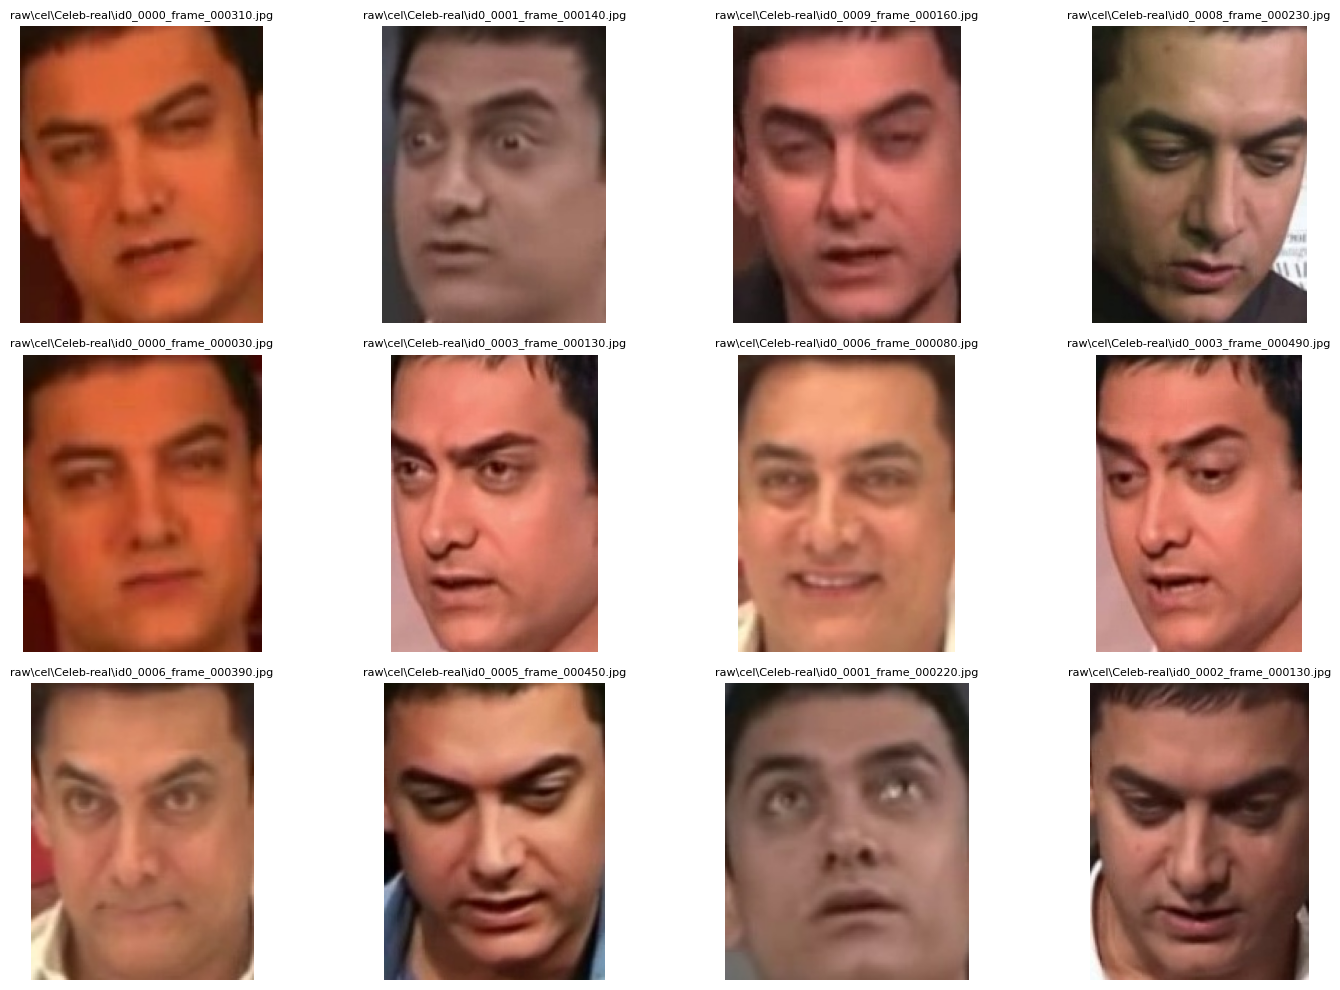

In [12]:
# ============================================================
# SANITY CHECK — view a sample of saved face crops
# ============================================================
import matplotlib.pyplot as plt

face_images = [os.path.join(r, f) for r, d, files in os.walk(FACES_DIR) for f in files if f.endswith(".jpg")]
print("Total face crops found:", len(face_images))

plt.figure(figsize=(15, 10))
for i, image_path in enumerate(face_images[:12]):
    image = Image.open(image_path)
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(os.path.basename(image_path), fontsize=8)
plt.tight_layout()
plt.show()